<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P4/E2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== HASIL UNTUK lena.jpg ===
Selisih Maksimum (Manual vs cv2.equalizeHist): 1



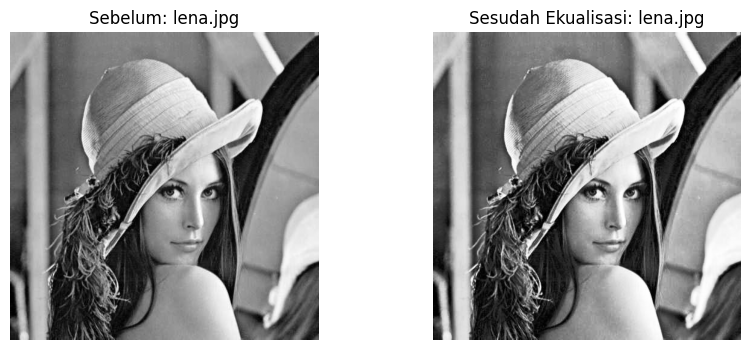

=== HASIL UNTUK KTM1a.jpg ===
Selisih Maksimum (Manual vs cv2.equalizeHist): 1



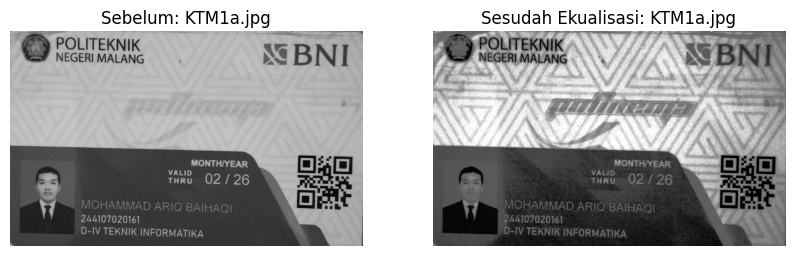

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = '/content/drive/MyDrive/PCVK_2026/'

def manual_histogram_equalization(img_gray):
    hist, _ = np.histogram(img_gray.flatten(), bins=256, range=[0, 256])

    cdf = hist.cumsum()
    cdf_normalized = cdf / img_gray.size

    skala_warna = np.round(cdf_normalized * 255).astype(np.uint8)

    img_equalized = skala_warna[img_gray]
    return img_equalized

for img_filename in ['lena.jpg', 'KTM1a.jpg']:
    path = os.path.join(BASE, img_filename)
    img_bgr = cv.imread(path)

    if img_bgr is None:
        print(f"Gambar tidak ditemukan di: {path}")
        continue

    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    manual_eq = manual_histogram_equalization(img_gray)

    cv_eq = cv.equalizeHist(img_gray)

    max_diff = np.max(np.abs(manual_eq.astype(int) - cv_eq.astype(int)))
    print(f"=== HASIL UNTUK {img_filename} ===")
    print(f"Selisih Maksimum (Manual vs cv2.equalizeHist): {max_diff}\n")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title(f'Sebelum: {img_filename}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(manual_eq, cmap='gray')
    plt.title(f'Sesudah Ekualisasi: {img_filename}')
    plt.axis('off')
    plt.show()